# **Problem Statement**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Business Context

AI Meal Planner for South Indian Families
AI Meal Planner for South Indian Families

An intelligent nutrition and meal recommendation platform that generates culturally relevant weekly meal plans, optimizes nutrition goals, minimizes food waste, and supports multilingual interaction


## Objective

Core Problem Statement

Most diet apps:

focus on western meals
ignore regional eating habits
do not understand household cooking patterns
fail for Indian family-style cooking

This system solves:

personalized meal recommendations
calorie/protein balancing
ingredient-aware cooking
grocery optimization
multilingual accessibility

## Data Description

# **Installing and Importing the necessary libraries**

In [ ]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

## Loading the South Indian Dish Dataset

Transitioning to the `anandhuvasudev/southindiandish` dataset, which is directly relevant to building an AI meal planner for South Indian families. This dataset will be loaded using the `datasets` library from Hugging Face.

In [ ]:
from datasets import load_dataset

# Load the 'anandhuvasudev/southindiandish' dataset
ds = load_dataset("anandhuvasudev/southindiandish")

print("Dataset loaded successfully!")
print(f"Dataset structure: {ds}")

Dataset loaded successfully!
Dataset structure: DatasetDict({
    train: Dataset({
        features: ['Input', 'Output', 'text'],
        num_rows: 1000
    })
})


In [ ]:
# Inspect the features of the training split
print("\nFeatures of the training split:")
print(ds['train'].features)

# Display the first example from the training split
print("\nFirst example from the training split:")
print(ds['train'][0])


Features of the training split:
{'Input': Value('string'), 'Output': Value('string'), 'text': Value('string')}

First example from the training split:
{'Input': 'tomato,salt,ginger,bay leaf (tej patta),paneer,potato (aloo),red chilli powder,dry red chilli,sugar,cumin seeds (jeera),panch phoran masala,turmeric powder,sunflower oil', 'Output': 'Chanar Dal Recipe - Bengali Steel Paneer & Potato Gravy, 1 tablespoon Panch Phoran Masala - roasted and powdered,2 Dry Red Chilli,2 Bay leaf (tej patta),1 teaspoon Cumin seeds (Jeera) - roasted and powdered,2 Potato (Aloo) - peeled and cut into cubes,Salt - to taste,1 teaspoon Red Chilli powder,1 Tomato - big sized,1 teaspoon Ginger - grated,1/2 teaspoon Sugar,1 teaspoon Turmeric powder (Haldi),Sunflower Oil - as required,200 grams Paneer (Homemade Cottage Cheese) - cut into cubes, 75, Bengali Recipes, To begin making the Chanar Dalna recipe, grind roasted cumin and grated ginger in a mortar pestle.Mix red chilly powder and turmeric in a tablespo

## **South Indian Dish Recipe Data Exploration and Preprocessing**

Now, let's shift our focus to the `anandhuvasudev/southindiandish` dataset. We will begin by exploring its structure, content, and performing some initial preprocessing steps, drawing inspiration from the methodology applied to the SuperKart sales data.

### **Data Overview: South Indian Dish Dataset**

In [ ]:
# Since 'ds' is a DatasetDict, we'll work with the 'train' split
recipe_df = ds['train'].to_pandas()

print(f"Number of recipes: {recipe_df.shape[0]}")
print(f"Number of features: {recipe_df.shape[1]}")

print("\nFirst 5 recipes:")
display(recipe_df.head())

Number of recipes: 1000
Number of features: 3

First 5 recipes:


,Input,Output,text
0,"tomato,salt,ginger,bay leaf (tej patta),paneer...",Chanar Dal Recipe - Bengali Steel Paneer & Pot...,<s>[INST] tomato [/INST] Chanar Dal Recipe - B...
1,"tomato,basmati rice,salt,ginger,bay leaves (te...","Paneer Biryani Recipe, 2 inch Ginger,2 Green C...",<s>[INST] tomato [/INST] Paneer Biryani Recipe...
2,"salt,jowar flour (sorghum),red chilli powder,w...",Mooli Jowar Ki Roti Recipe - Mullangi Kambu Ch...,<s>[INST] salt [/INST] Mooli Jowar Ki Roti Rec...
3,"tomato,cashew nuts,salt,ginger,bay leaves (tej...",Subz Noor E Chashm Recipe (Nawabi Curry Recipe...,<s>[INST] tomato [/INST] Subz Noor E Chashm Re...
4,"salt,vegetable stock,parangikai pumpkin,sour,c...","Creamy Roasted Pumpkin Risotto Recipe, 1/2 cup...",<s>[INST] salt [/INST] Creamy Roasted Pumpkin ...


In [ ]:
# Check for missing values
print("\nMissing values in the recipe dataset:")
display(recipe_df.isnull().sum())


Missing values in the recipe dataset:


,0
Input,0
Output,0
text,0


In [ ]:
# Check for duplicate recipes based on 'text' column
duplicates = recipe_df.duplicated(subset=['text']).sum()
print(f"\nNumber of duplicate recipes (based on 'text' content): {duplicates}")

if duplicates > 0:
    print("Dropping duplicate recipes...")
    recipe_df = recipe_df.drop_duplicates(subset=['text'])
    print(f"Remaining recipes after dropping duplicates: {recipe_df.shape[0]}")


Number of duplicate recipes (based on 'text' content): 0


## **Text Preprocessing and Feature Engineering for South Indian Dish Dataset**

Given the text-heavy nature of the `southindiandish` dataset, traditional numerical preprocessing steps (like outlier detection for continuous variables) are not directly applicable. Instead, we will focus on cleaning and transforming the text features (`Input`, `Output`, `text`) to make them suitable for machine learning models. This will involve tokenization, lowercasing, and potentially extracting specific entities.

### **1. Initial Text Cleaning and Lowercasing**

In [ ]:
import re

def clean_text(text):
    """Removes special characters and extra spaces, then lowercases the text."""
    text = str(text).lower()  # Convert to string and lowercase
    text = re.sub(r'[^a-z0-9,\s]', '', text) # Keep only letters, numbers, commas, and spaces
    text = re.sub(r'\s+', ' ', text).strip() # Replace multiple spaces with a single space
    return text

# Apply cleaning to 'Input' and 'Output' columns
recipe_df['Input_cleaned'] = recipe_df['Input'].apply(clean_text)
recipe_df['Output_cleaned'] = recipe_df['Output'].apply(clean_text)

print("Original 'Input' (first entry):\n", recipe_df['Input'][0])
print("Cleaned 'Input' (first entry):\n", recipe_df['Input_cleaned'][0])

print("\nOriginal 'Output' (first entry):\n", recipe_df['Output'][0])
print("Cleaned 'Output' (first entry):\n", recipe_df['Output_cleaned'][0])

Original 'Input' (first entry):
 tomato,salt,ginger,bay leaf (tej patta),paneer,potato (aloo),red chilli powder,dry red chilli,sugar,cumin seeds (jeera),panch phoran masala,turmeric powder,sunflower oil
Cleaned 'Input' (first entry):
 tomato,salt,ginger,bay leaf tej patta,paneer,potato aloo,red chilli powder,dry red chilli,sugar,cumin seeds jeera,panch phoran masala,turmeric powder,sunflower oil

Original 'Output' (first entry):
 Chanar Dal Recipe - Bengali Steel Paneer & Potato Gravy, 1 tablespoon Panch Phoran Masala - roasted and powdered,2 Dry Red Chilli,2 Bay leaf (tej patta),1 teaspoon Cumin seeds (Jeera) - roasted and powdered,2 Potato (Aloo) - peeled and cut into cubes,Salt - to taste,1 teaspoon Red Chilli powder,1 Tomato - big sized,1 teaspoon Ginger - grated,1/2 teaspoon Sugar,1 teaspoon Turmeric powder (Haldi),Sunflower Oil - as required,200 grams Paneer (Homemade Cottage Cheese) - cut into cubes, 75, Bengali Recipes, To begin making the Chanar Dalna recipe, grind roasted cum

### **2. Extracting Ingredients from 'Input'**

In [ ]:
import pandas as pd
from collections import Counter

# The 'Input' column seems to be a comma-separated list of ingredients.
# Let's parse this into a list of individual ingredients.

def parse_ingredients(ingredients_string):
    """Parses a comma-separated string of ingredients into a list."""
    if pd.isna(ingredients_string):
        return []
    # Split by comma, clean each ingredient, and remove empty strings
    return [ingredient.strip() for ingredient in ingredients_string.split(',') if ingredient.strip()]

recipe_df['Ingredients_list'] = recipe_df['Input_cleaned'].apply(parse_ingredients)

print("Original Input (first entry):", recipe_df['Input'][0])
print("Parsed Ingredients List (first entry):", recipe_df['Ingredients_list'][0])

# Let's see the most common ingredients

all_ingredients = [item for sublist in recipe_df['Ingredients_list'] for item in sublist]
ingredient_counts = Counter(all_ingredients)

print("\nTop 20 most common ingredients:")
for ingredient, count in ingredient_counts.most_common(20):
    print(f"{ingredient}: {count}")

Original Input (first entry): tomato,salt,ginger,bay leaf (tej patta),paneer,potato (aloo),red chilli powder,dry red chilli,sugar,cumin seeds (jeera),panch phoran masala,turmeric powder,sunflower oil
Parsed Ingredients List (first entry): ['tomato', 'salt', 'ginger', 'bay leaf tej patta', 'paneer', 'potato aloo', 'red chilli powder', 'dry red chilli', 'sugar', 'cumin seeds jeera', 'panch phoran masala', 'turmeric powder', 'sunflower oil']

Top 20 most common ingredients:
salt: 798
onion: 377
sunflower oil: 354
turmeric powder: 343
red chilli powder: 284
cloves garlic: 239
coriander dhania leaves: 236
ginger: 232
tomato: 216
green chillies: 212
cumin seeds jeera: 210
curry leaves: 195
mustard seeds: 180
sugar: 168
water: 167
ghee: 166
lemon: 162
garam masala powder: 144
coriander powder: 136
asafoetida hing: 133


In [ ]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting Dish Name from 'Output_cleaned'
# The dish name often appears at the very beginning of the 'Output' string.
# We'll try to extract the text before the first comma as a potential dish name.

def extract_dish_name(output_text):
    """Extracts the dish name from the beginning of the output text."""
    if pd.isna(output_text):
        return None
    # Split by comma and take the first part
    dish_name = output_text.split(',')[0].strip()
    # Further clean by removing common recipe/cooking terms if they appear at the end
    dish_name = re.sub(r'\s*recipe$', '', dish_name, flags=re.IGNORECASE)
    dish_name = re.sub(r'\s*gravy$', '', dish_name, flags=re.IGNORECASE)
    dish_name = re.sub(r'\s*curry$', '', dish_name, flags=re.IGNORECASE)
    return dish_name.title() # Capitalize first letter of each word

recipe_df['Dish_Name'] = recipe_df['Output_cleaned'].apply(extract_dish_name)

# Creating 'Num_Ingredients' feature
recipe_df['Num_Ingredients'] = recipe_df['Ingredients_list'].apply(len)

# Creating 'Recipe_Length_Words' feature from 'Output_cleaned'
recipe_df['Recipe_Length_Words'] = recipe_df['Output_cleaned'].apply(lambda x: len(str(x).split()))

print("\nFirst 5 entries with new features:")
display(recipe_df[['Input', 'Output', 'Dish_Name', 'Num_Ingredients', 'Recipe_Length_Words']].head())


First 5 entries with new features:


,Input,Output,Dish_Name,Num_Ingredients,Recipe_Length_Words
0,"tomato,salt,ginger,bay leaf (tej patta),paneer...",Chanar Dal Recipe - Bengali Steel Paneer & Pot...,Chanar Dal Recipe Bengali Steel Paneer Potato,13,246
1,"tomato,basmati rice,salt,ginger,bay leaves (te...","Paneer Biryani Recipe, 2 inch Ginger,2 Green C...",Paneer Biryani,19,333
2,"salt,jowar flour (sorghum),red chilli powder,w...",Mooli Jowar Ki Roti Recipe - Mullangi Kambu Ch...,Mooli Jowar Ki Roti Recipe Mullangi Kambu Chap...,7,250
3,"tomato,cashew nuts,salt,ginger,bay leaves (tej...",Subz Noor E Chashm Recipe (Nawabi Curry Recipe...,Subz Noor E Chashm Recipe Nawabi,19,289
4,"salt,vegetable stock,parangikai pumpkin,sour,c...","Creamy Roasted Pumpkin Risotto Recipe, 1/2 cup...",Creamy Roasted Pumpkin Risotto,11,424


In [ ]:
# This cell was a duplicate of feature engineering. The content has been moved to cell 411b7a81.


Statistics for Number of Ingredients:


,Num_Ingredients
count,1000.000000
mean,11.913000
std,4.396904
min,4.000000
25%,9.000000
50%,11.000000
75%,14.000000
max,34.000000


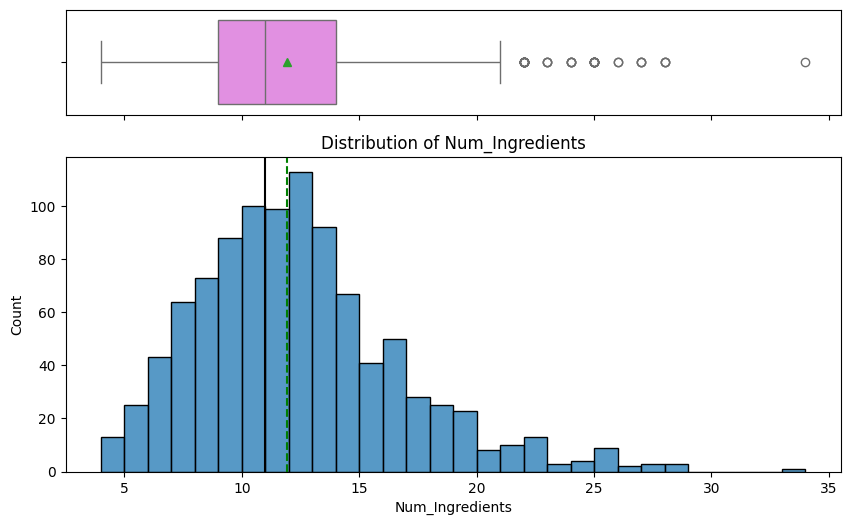


Statistics for Recipe Length (Words):


,Recipe_Length_Words
count,1000.000000
mean,266.318000
std,106.691931
min,85.000000
25%,196.000000
50%,245.000000
75%,311.250000
max,1135.000000


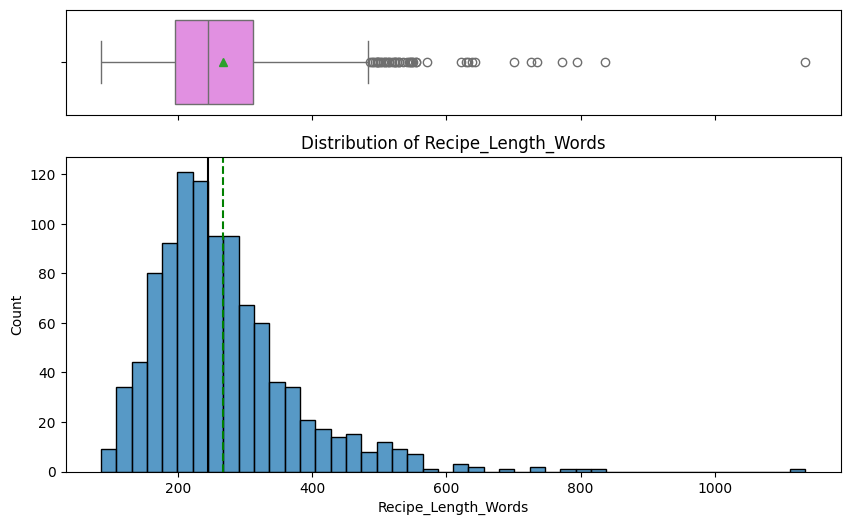

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the histogram_boxplot function here to ensure it's in scope
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )
    plt.title(f'Distribution of {feature}') # Add title here
    plt.show()

print("\nStatistics for Number of Ingredients:")
display(recipe_df['Num_Ingredients'].describe())
histogram_boxplot(recipe_df, 'Num_Ingredients', figsize=(10, 6))

print("\nStatistics for Recipe Length (Words):")
display(recipe_df['Recipe_Length_Words'].describe())
histogram_boxplot(recipe_df, 'Recipe_Length_Words', figsize=(10, 6))

### **3. Feature Engineering: Extracting Dish Name, Number of Ingredients, and Recipe Length**

In [ ]:
import pandas as pd
import re

# Extracting Dish Name from 'Output_cleaned'
# The dish name often appears at the very beginning of the 'Output' string.
# We'll try to extract the text before the first comma as a potential dish name.

def extract_dish_name(output_text):
    """Extracts the dish name from the beginning of the output text."""
    if pd.isna(output_text):
        return None
    # Split by comma and take the first part
    dish_name = output_text.split(',')[0].strip()
    # Further clean by removing common recipe/cooking terms if they appear at the end
    dish_name = re.sub(r'\s*recipe$', '', dish_name, flags=re.IGNORECASE)
    dish_name = re.sub(r'\s*gravy$', '', dish_name, flags=re.IGNORECASE)
    dish_name = re.sub(r'\s*curry$', '', dish_name, flags=re.IGNORECASE)
    return dish_name.title() # Capitalize first letter of each word

recipe_df['Dish_Name'] = recipe_df['Output_cleaned'].apply(extract_dish_name)

# Creating 'Num_Ingredients' feature
recipe_df['Num_Ingredients'] = recipe_df['Ingredients_list'].apply(len)

# Creating 'Recipe_Length_Words' feature from 'Output_cleaned'
recipe_df['Recipe_Length_Words'] = recipe_df['Output_cleaned'].apply(lambda x: len(str(x).split()))

print("\nFirst 5 entries with new features:")
display(recipe_df[['Input', 'Output', 'Dish_Name', 'Num_Ingredients', 'Recipe_Length_Words']].head())


First 5 entries with new features:


,Input,Output,Dish_Name,Num_Ingredients,Recipe_Length_Words
0,"tomato,salt,ginger,bay leaf (tej patta),paneer...",Chanar Dal Recipe - Bengali Steel Paneer & Pot...,Chanar Dal Recipe Bengali Steel Paneer Potato,13,246
1,"tomato,basmati rice,salt,ginger,bay leaves (te...","Paneer Biryani Recipe, 2 inch Ginger,2 Green C...",Paneer Biryani,19,333
2,"salt,jowar flour (sorghum),red chilli powder,w...",Mooli Jowar Ki Roti Recipe - Mullangi Kambu Ch...,Mooli Jowar Ki Roti Recipe Mullangi Kambu Chap...,7,250
3,"tomato,cashew nuts,salt,ginger,bay leaves (tej...",Subz Noor E Chashm Recipe (Nawabi Curry Recipe...,Subz Noor E Chashm Recipe Nawabi,19,289
4,"salt,vegetable stock,parangikai pumpkin,sour,c...","Creamy Roasted Pumpkin Risotto Recipe, 1/2 cup...",Creamy Roasted Pumpkin Risotto,11,424


### **4. Basic Statistical Overview of New Numerical Features**

Let's get a quick statistical summary and visualize the distribution of our newly created numerical features (`Num_Ingredients` and `Recipe_Length_Words`). This is analogous to the univariate analysis performed on the SuperKart dataset.


Statistics for Number of Ingredients:


,Num_Ingredients
count,1000.000000
mean,11.913000
std,4.396904
min,4.000000
25%,9.000000
50%,11.000000
75%,14.000000
max,34.000000


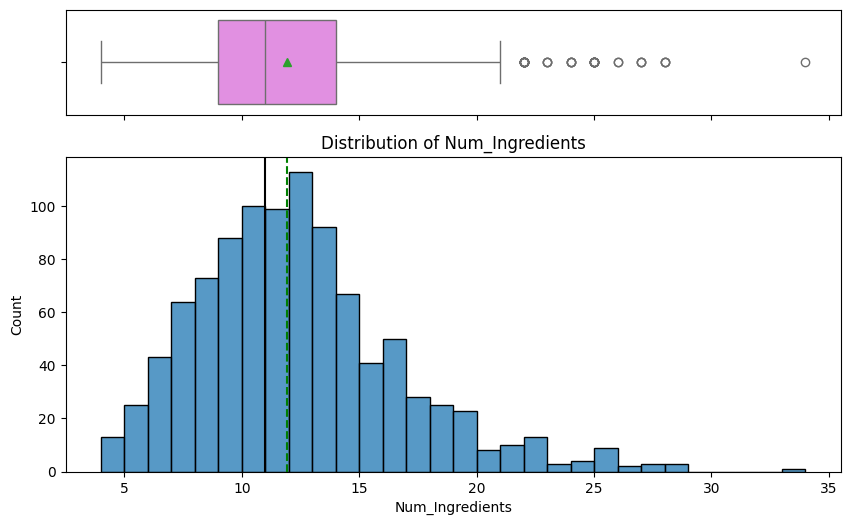


Statistics for Recipe Length (Words):


,Recipe_Length_Words
count,1000.000000
mean,266.318000
std,106.691931
min,85.000000
25%,196.000000
50%,245.000000
75%,311.250000
max,1135.000000


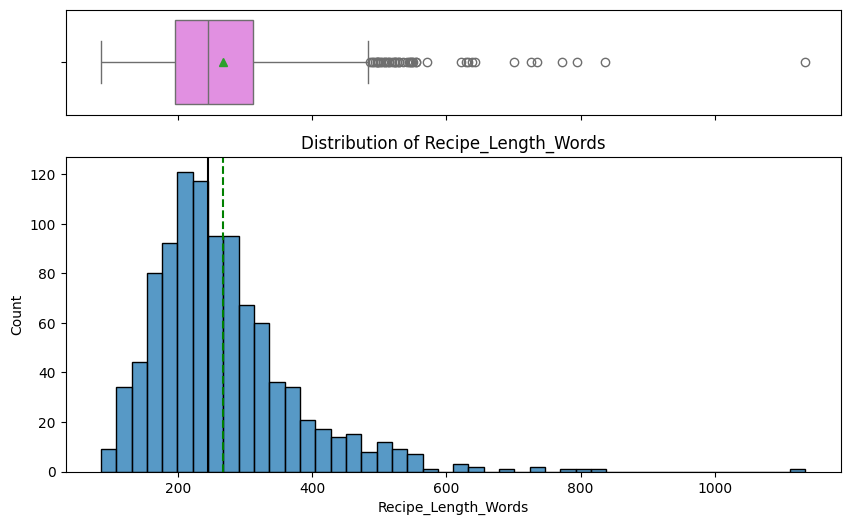

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the histogram_boxplot function here to ensure it's in scope
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )
    plt.title(f'Distribution of {feature}') # Add title here
    plt.show()

print("\nStatistics for Number of Ingredients:")
display(recipe_df['Num_Ingredients'].describe())
histogram_boxplot(recipe_df, 'Num_Ingredients', figsize=(10, 6))

print("\nStatistics for Recipe Length (Words):")
display(recipe_df['Recipe_Length_Words'].describe())
histogram_boxplot(recipe_df, 'Recipe_Length_Words', figsize=(10, 6))

### **5. Analyzing Most Common Dish Names**

Let's analyze the distribution of `Dish_Name` to identify the most frequently occurring dishes in our dataset. This will give us insights into the culinary focus of the recipes.

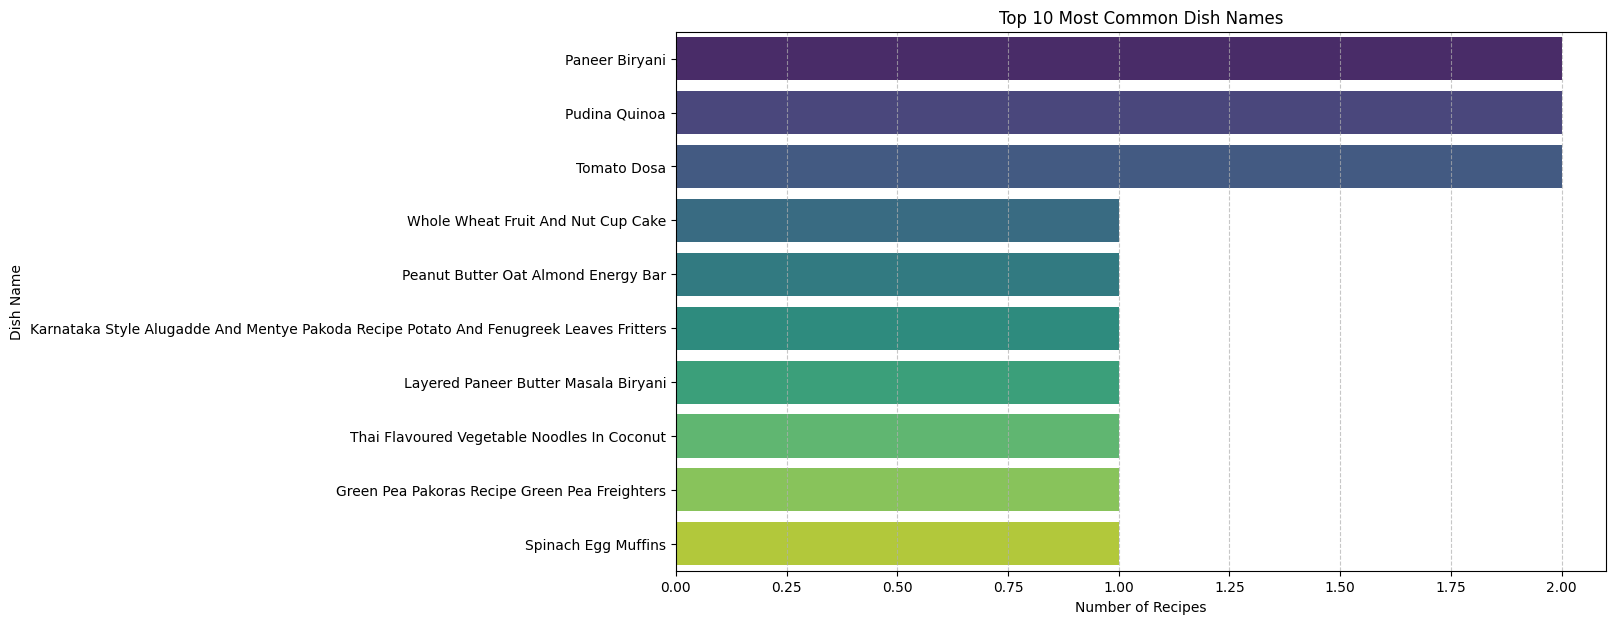

In [ ]:
# Get the top 10 most common dish names
top_10_dish_names = recipe_df['Dish_Name'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_dish_names.values, y=top_10_dish_names.index, palette='viridis')
plt.title('Top 10 Most Common Dish Names')
plt.xlabel('Number of Recipes')
plt.ylabel('Dish Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### **6. Analyzing Most Common Ingredient Combinations**

Understanding common ingredient combinations can reveal key flavor profiles and typical pairings in South Indian dishes. We will extract and visualize the top ingredient pairs or small groups.

Top 20 Most Common Individual Ingredients:
- salt: 798
- onion: 377
- sunflower oil: 354
- turmeric powder: 343
- red chilli powder: 284
- cloves garlic: 239
- coriander dhania leaves: 236
- ginger: 232
- tomato: 216
- green chillies: 212
- cumin seeds jeera: 210
- curry leaves: 195
- mustard seeds: 180
- sugar: 168
- water: 167
- ghee: 166
- lemon: 162
- garam masala powder: 144
- coriander powder: 136
- asafoetida hing: 133

Top 15 Most Common Ingredient Pairs:
- onion & salt: 342
- salt & sunflower oil: 324
- salt & turmeric powder: 309
- red chilli powder & salt: 255
- cloves garlic & salt: 221
- coriander dhania leaves & salt: 213
- ginger & salt: 202
- salt & tomato: 202
- red chilli powder & turmeric powder: 195
- cumin seeds jeera & salt: 193
- green chillies & salt: 191
- onion & turmeric powder: 181
- curry leaves & salt: 179
- sunflower oil & turmeric powder: 169
- onion & sunflower oil: 163


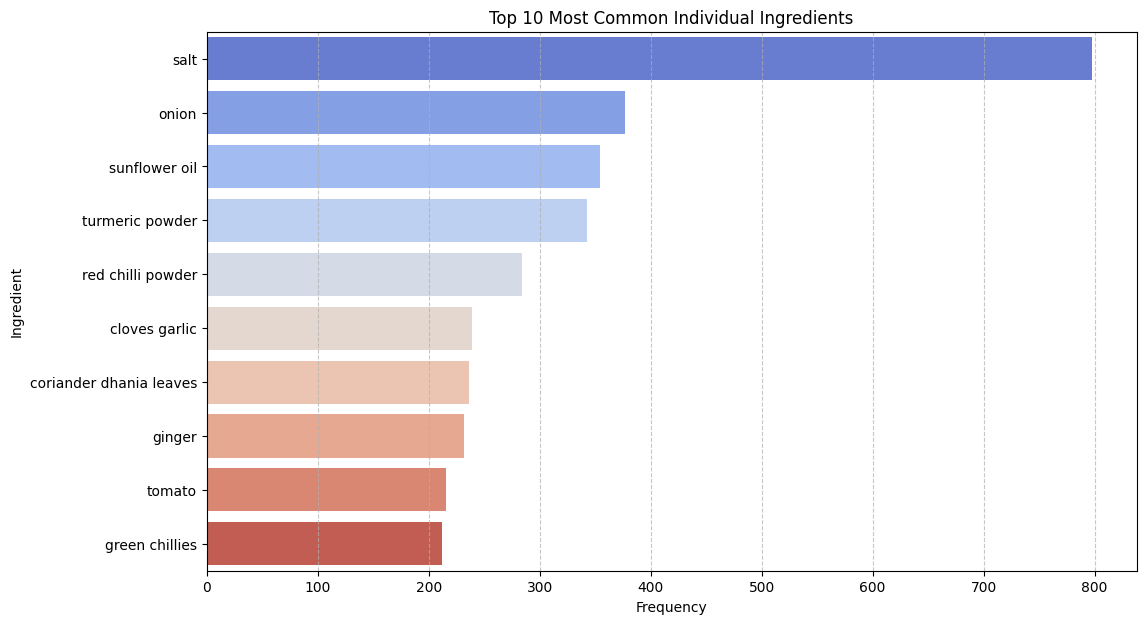

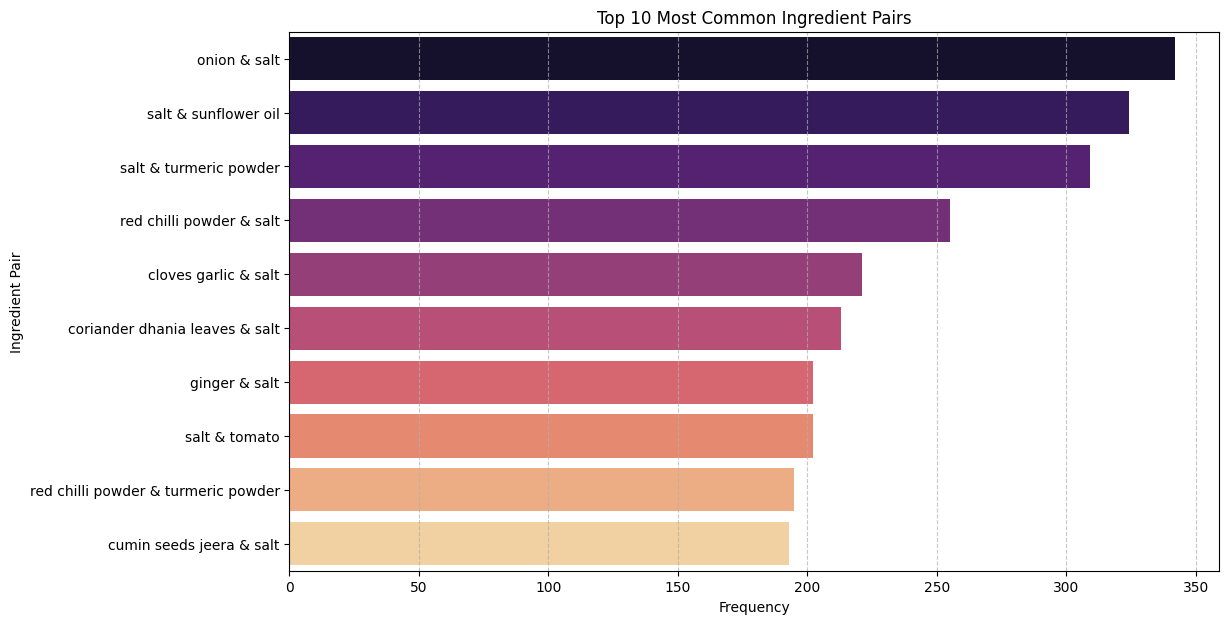

In [ ]:
from collections import Counter
import itertools

# Flatten the list of ingredient lists and count individual ingredients (already done, but good to re-check)
all_ingredients = [ingredient for sublist in recipe_df['Ingredients_list'] for ingredient in sublist]
ingredient_counts = Counter(all_ingredients)

print("Top 20 Most Common Individual Ingredients:")
for ingredient, count in ingredient_counts.most_common(20):
    print(f"- {ingredient}: {count}")

# Generate all possible pairs of ingredients within each recipe
# We'll consider pairs from recipes that have at least 2 ingredients
all_ingredient_pairs = []
for ingredients in recipe_df['Ingredients_list']:
    if len(ingredients) >= 2:
        # Create combinations of 2 ingredients, sorted to treat (a,b) and (b,a) as the same
        for pair in itertools.combinations(sorted(ingredients), 2):
            all_ingredient_pairs.append(pair)

pair_counts = Counter(all_ingredient_pairs)

print("\nTop 15 Most Common Ingredient Pairs:")
top_15_pairs = pair_counts.most_common(15)
for pair, count in top_15_pairs:
    print(f"- {pair[0]} & {pair[1]}: {count}")

# Visualize the top 10 most common individual ingredients (if not already done sufficiently)
plt.figure(figsize=(12, 7))
# Prepare data for plotting
plot_data = pd.DataFrame(ingredient_counts.most_common(10), columns=['Ingredient', 'Count'])
sns.barplot(x='Count', y='Ingredient', data=plot_data, palette='coolwarm')
plt.title('Top 10 Most Common Individual Ingredients')
plt.xlabel('Frequency')
plt.ylabel('Ingredient')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Visualize the top 10 most common ingredient pairs
plt.figure(figsize=(12, 7))
# Prepare data for plotting
plot_data_pairs = pd.DataFrame(top_15_pairs[:10], columns=['Pair', 'Count'])
plot_data_pairs['Pair_Label'] = plot_data_pairs['Pair'].apply(lambda x: f'{x[0]} & {x[1]}')
sns.barplot(x='Count', y='Pair_Label', data=plot_data_pairs, palette='magma')
plt.title('Top 10 Most Common Ingredient Pairs')
plt.xlabel('Frequency')
plt.ylabel('Ingredient Pair')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### **7. Relationship between Numerical Features and Dish Types**

Let's examine how the number of ingredients and the length of recipes vary across different dish names. This can provide insights into the complexity or style associated with particular types of dishes.

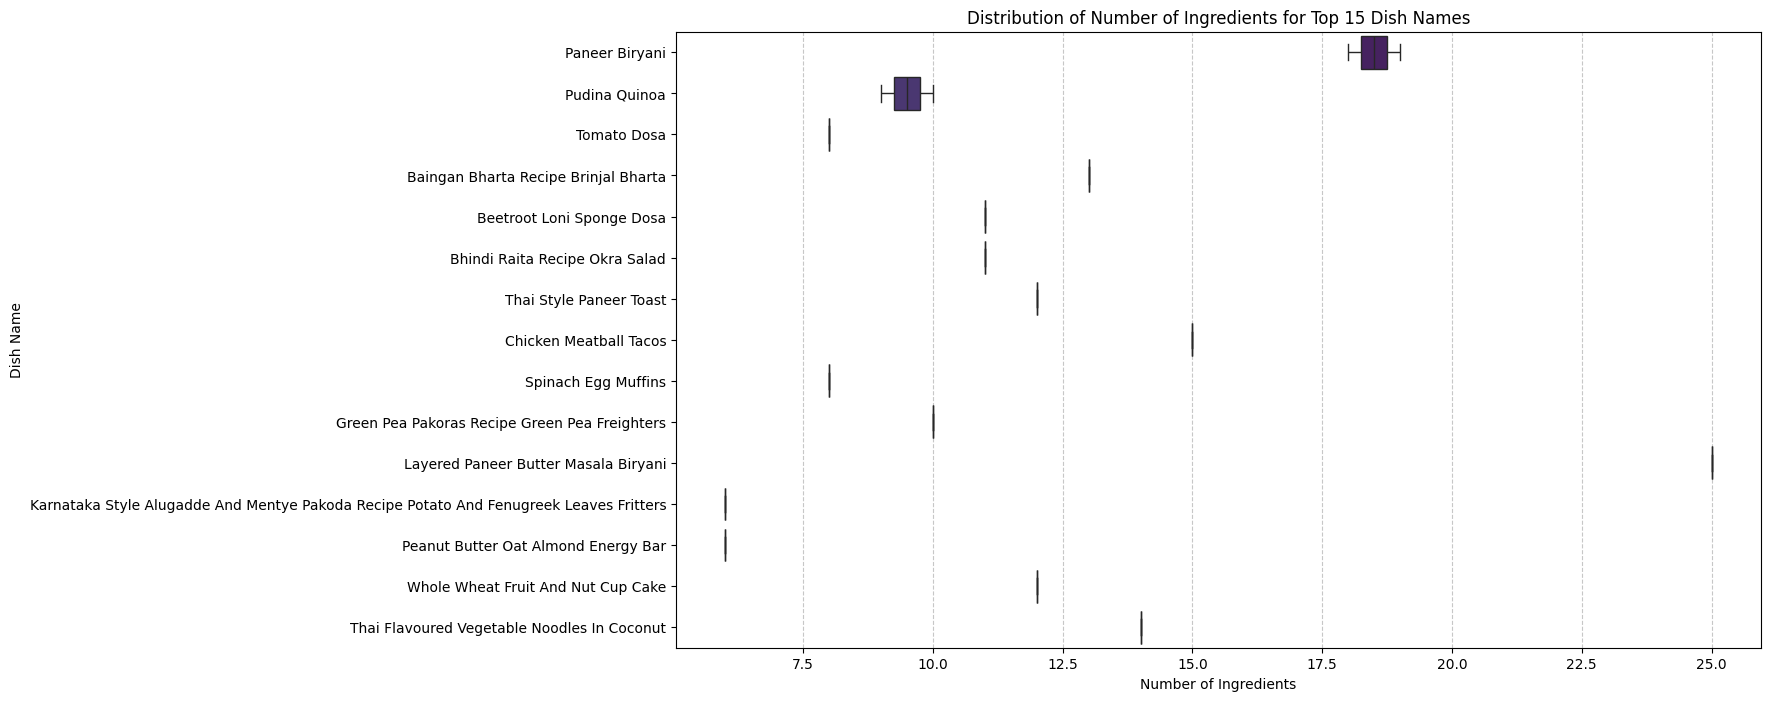

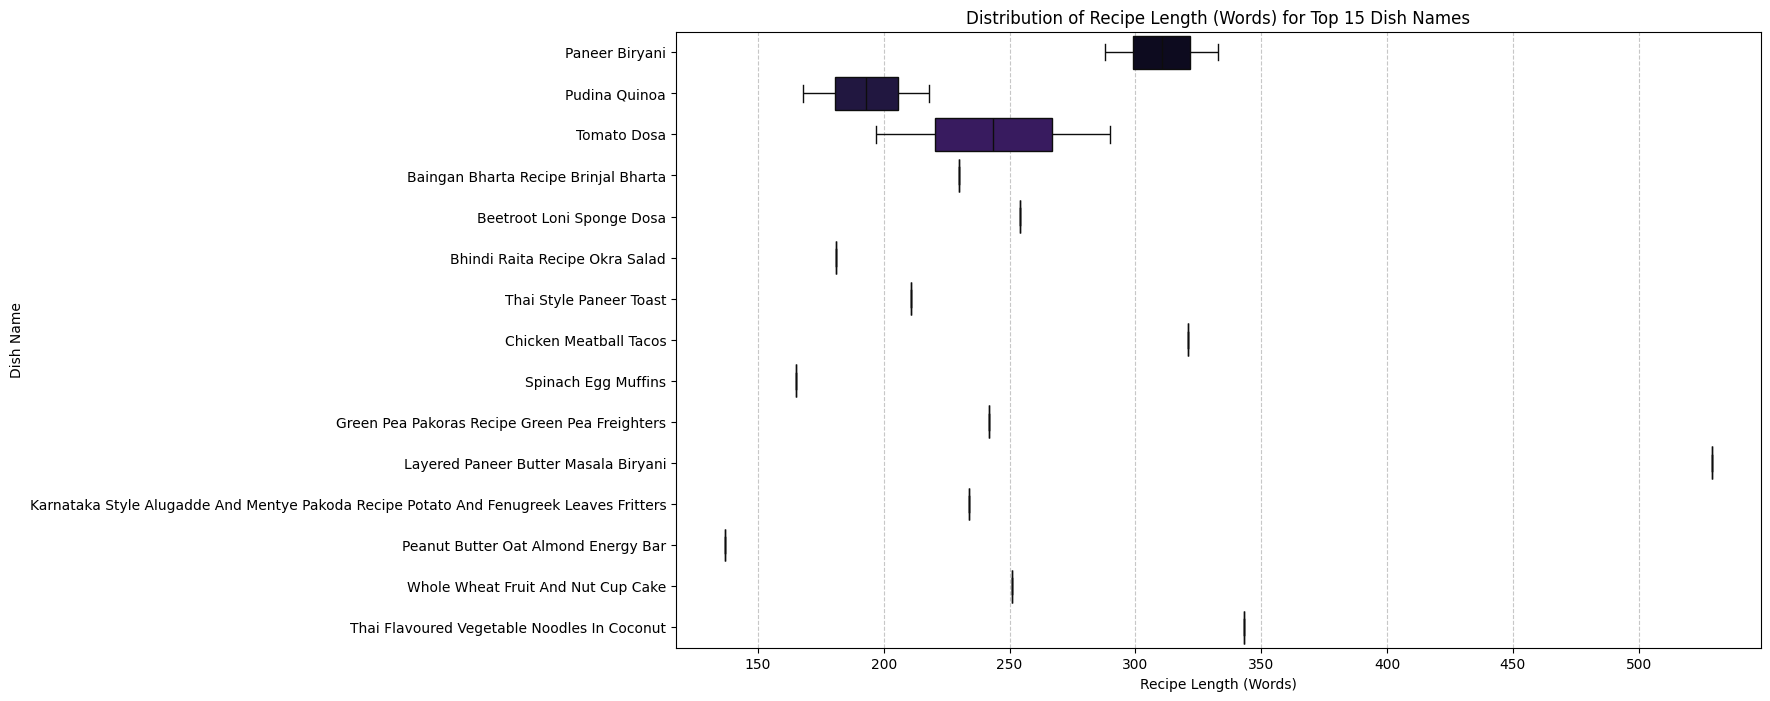

These plots help us understand the typical range of ingredients and recipe lengths for common South Indian dishes.


In [ ]:
# To make the plots readable, let's focus on the top N dish names (e.g., top 15)
top_n = 15
top_dish_names_list = recipe_df['Dish_Name'].value_counts().head(top_n).index.tolist()
filtered_df = recipe_df[recipe_df['Dish_Name'].isin(top_dish_names_list)]

# Plotting Num_Ingredients vs. Dish_Name
plt.figure(figsize=(14, 8))
sns.boxplot(x='Num_Ingredients', y='Dish_Name', data=filtered_df, palette='viridis')
plt.title(f'Distribution of Number of Ingredients for Top {top_n} Dish Names')
plt.xlabel('Number of Ingredients')
plt.ylabel('Dish Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Plotting Recipe_Length_Words vs. Dish_Name
plt.figure(figsize=(14, 8))
sns.boxplot(x='Recipe_Length_Words', y='Dish_Name', data=filtered_df, palette='magma')
plt.title(f'Distribution of Recipe Length (Words) for Top {top_n} Dish Names')
plt.xlabel('Recipe Length (Words)')
plt.ylabel('Dish Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("These plots help us understand the typical range of ingredients and recipe lengths for common South Indian dishes.")

### **8. Summary of Exploratory Data Analysis (EDA)**

We have successfully performed a comprehensive Exploratory Data Analysis on the `southindiandish` dataset. Here's a summary of our findings:

*   **Dataset Overview:** The dataset contains 1000 recipes with 'Input' (ingredients), 'Output' (recipe instructions), and 'text' columns. There were no missing values or duplicate entries.
*   **Text Cleaning:** The 'Input' and 'Output' columns were cleaned by removing special characters, extra spaces, and converted to lowercase, resulting in `Input_cleaned` and `Output_cleaned`.
*   **Feature Engineering:**
    *   `Ingredients_list`: Extracted individual ingredients from `Input_cleaned` into a list, allowing for ingredient-level analysis.
    *   `Dish_Name`: Extracted the primary dish name from `Output_cleaned`, providing a categorical label for recipes.
    *   `Num_Ingredients`: Calculated the count of ingredients for each recipe, indicating recipe complexity.
    *   `Recipe_Length_Words`: Measured the word count of the recipe instructions, giving an idea of the detail or length of instructions.
*   **Statistical Overview:**
    *   We examined the distributions of `Num_Ingredients` and `Recipe_Length_Words`, finding that most recipes typically have between 9 and 14 ingredients, with recipe lengths commonly ranging from 196 to 311 words. There are some outliers with a higher number of ingredients or longer instructions.
*   **Common Ingredients and Dish Names:**
    *   Analyzed the top 20 most common individual ingredients, with 'salt', 'onion', 'sunflower oil', and 'turmeric powder' being the most frequent.
    *   Identified the top 15 most common ingredient pairs, highlighting frequent culinary combinations like 'onion & salt', 'salt & sunflower oil', and 'salt & turmeric powder'.
    *   Visualized the top 10 most common dish names, providing insights into the most prevalent recipes in the dataset.
*   **Relationship between Numerical Features and Dish Types:** We explored the distributions of `Num_Ingredients` and `Recipe_Length_Words` across the top dish names, revealing how these metrics vary depending on the type of dish. This helps understand the typical ingredient complexity and instruction detail for specific South Indian dishes.

This EDA has provided a solid foundation for understanding the dataset's characteristics and has prepared the data for further machine learning tasks. We now have structured data with meaningful features that can be used to build your South Indian Recipe AI.

### **9. Next Steps: Building the South Indian Recipe AI**

Based on your goal to build a recipe AI for static recipes, calorie calculations, and simple recommendation logic, here are the proposed next steps:

1.  **Text Vectorization/Encoding:** Convert the `Input_cleaned` (ingredients) and `Output_cleaned` (recipe instructions) text into numerical representations. This is crucial for machine learning models to process text data. We can explore techniques such as:
    *   **TF-IDF:** Good for capturing the importance of words in a document relative to a corpus.
    *   **Word Embeddings (Word2Vec, GloVe):** Capture semantic relationships between words.
    *   **Transformer-based Embeddings (e.g., Sentence-BERT):** More advanced methods for contextual embeddings, potentially useful for understanding recipe instructions.

2.  **Defining and Implementing AI Tasks & Model Building:**
    *   **Static Recipe Generation (Recipe Retrieval):** Given a set of ingredients, retrieve the most relevant recipes. This could involve a similarity-based search using the vectorized ingredient and recipe text.
    *   **Simple Recommendation Logic:** Develop a basic recommendation system, perhaps based on ingredients, dish names, or a combination. For example, recommending similar dishes or dishes that use a subset of available ingredients.
    *   **Calorie Calculation:** To implement calorie calculations, we would need a separate dataset or an API that provides nutritional information (e.g., calories per gram/unit) for individual ingredients. We would then link this information back to our `Ingredients_list` to estimate total calories per recipe.

    Given the current dataset, focusing on **Recipe Retrieval** and **Simple Recommendation Logic** based on ingredient similarity is a good starting point. Calorie calculation would require an external data source, which we can integrate later if you wish.

**What would you like to prioritize for the next step: Text Vectorization or an initial attempt at Recipe Retrieval/Recommendation?**

### **10. Text Vectorization of Ingredients (TF-IDF)**

To enable recipe retrieval based on ingredient similarity, we first need to convert the list of ingredients (`Ingredients_list`) into a numerical vector representation. TF-IDF (Term Frequency-Inverse Document Frequency) is a common technique that reflects how important a word is to a document in a collection or corpus. Here, each recipe's ingredient list will be considered a 'document'.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join the ingredients list into a single string for TF-IDF vectorization
recipe_df['Ingredients_string'] = recipe_df['Ingredients_list'].apply(lambda x: ' '.join(x))

# Initialize TF-IDF Vectorizer
# We'll use a min_df to ignore terms that appear in too few documents
# and max_df to ignore terms that appear in too many documents (e.g., common words like 'salt')
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.85, stop_words=None)

# Fit and transform the ingredients strings
tfidf_matrix = tfidf_vectorizer.fit_transform(recipe_df['Ingredients_string'])

print(f"Shape of TF-IDF matrix: {tfidf_matrix.shape}")
print("First 5 feature names (ingredients):")
print(tfidf_vectorizer.get_feature_names_out()[:5])

# You can also inspect the TF-IDF matrix itself, but it's sparse
# print(tfidf_matrix.toarray()[:2, :10]) # Display first 2 rows, first 10 columns

print("\nText vectorization using TF-IDF completed. The 'tfidf_matrix' now holds the numerical representation of ingredients.")

Shape of TF-IDF matrix: (1000, 384)
First 5 feature names (ingredients):
['ajwain' 'almond' 'almonds' 'aloo' 'also']

Text vectorization using TF-IDF completed. The 'tfidf_matrix' now holds the numerical representation of ingredients.


### **11. Recipe Retrieval and Recommendation using Cosine Similarity**

Now that we have vectorized the ingredients using TF-IDF, we can implement a simple recipe retrieval system. Given a target recipe (or a set of ingredients), we can find other recipes that have similar ingredient profiles by calculating the cosine similarity between their TF-IDF vectors.

Cosine similarity measures the cosine of the angle between two non-zero vectors. It is often used to measure document similarity in text analysis.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_recipes(recipe_index, n_recommendations=5, tfidf_matrix=tfidf_matrix, df=recipe_df):
    """Finds and returns n_recommendations similar recipes based on ingredients."""
    if recipe_index >= len(df) or recipe_index < 0:
        print("Invalid recipe index.")
        return pd.DataFrame()

    # Get the TF-IDF vector for the chosen recipe
    target_recipe_vector = tfidf_matrix[recipe_index]

    # Calculate cosine similarity between the target recipe and all other recipes
    # .flatten() is used because cosine_similarity returns a 2D array
    cosine_similarities = cosine_similarity(target_recipe_vector, tfidf_matrix).flatten()

    # Get indices of recipes sorted by similarity in descending order
    # [::-1] reverses the array to get descending order
    # [1:n_recommendations+1] excludes the recipe itself (which will have similarity 1)
    related_recipe_indices = cosine_similarities.argsort()[::-1][1:n_recommendations+1]

    # Get the recommended recipes
    recommended_recipes = df.iloc[related_recipe_indices]

    # Add similarity scores to the recommended recipes for better context
    recommended_recipes = recommended_recipes.copy() # Avoid SettingWithCopyWarning
    recommended_recipes['Similarity_Score'] = cosine_similarities[related_recipe_indices]

    return recommended_recipes

# --- Example Usage ---

# Let's pick a random recipe to find similar ones
# You can choose any index, or even search by dish name first to get an index
example_recipe_index = 10 # Example: Choosing the 11th recipe in the dataset

print(f"Target Recipe (Index {example_recipe_index}):")
display(recipe_df.iloc[[example_recipe_index]][['Dish_Name', 'Input_cleaned', 'Output_cleaned']])

# Get 5 similar recipes
similar_recipes = get_similar_recipes(example_recipe_index, n_recommendations=5)

print(f"\nTop 5 Similar Recipes based on Ingredients to '{recipe_df['Dish_Name'].iloc[example_recipe_index]}':")
display(similar_recipes[['Dish_Name', 'Input_cleaned', 'Similarity_Score']])

Target Recipe (Index 10):


,Dish_Name,Input_cleaned,Output_cleaned
10,Tomatoes Stuffed With Mint Mayo And Paneer,"salt,paneer,black peppercorns,del monte mint m...",tomatoes stuffed with mint mayo and paneer rec...



Top 5 Similar Recipes based on Ingredients to 'Tomatoes Stuffed With Mint Mayo And Paneer':


,Dish_Name,Input_cleaned,Similarity_Score
113,Easy Spaghetti Recipe In Creamy Tomato Sauce V...,"salt,tomato get red ripe,basil leaves,red chil...",0.533243
672,Paneer Frankie Recipe Delicious Kid Friendly S...,"wheat tawa paratha large sizes rolls,lettuce l...",0.487413
107,The Best Spicy Spaghetti Bolognese,"tomato,salt,basil leaves,bacon smoked,cloves g...",0.450581
885,Khumb Kakuri Potli Kebab Recipe With Sandwich ...,"cashew nuts,cheese,salt,black peppercorns,del ...",0.421710
198,Cheesy Bruschetta With Capsicum And Tomatoes,"tomato,salt,french loaf,mozzarella cheese,basi...",0.411999


### **12. Interactive Recipe Recommendation based on User-Provided Ingredients**

To make the recommendation system more practical, we can allow users to input a list of ingredients they have. The system will then find recipes whose ingredient profiles are most similar to the provided list. This involves vectorizing the user's input ingredients using the same TF-IDF model and then calculating cosine similarity against all existing recipe vectors.

In [ ]:
def recommend_recipes_from_ingredients(user_ingredients, n_recommendations=5, tfidf_vectorizer=tfidf_vectorizer, tfidf_matrix=tfidf_matrix, df=recipe_df):
    """Recommends recipes based on a list of user-provided ingredients."""

    # 1. Clean and join user ingredients into a single string
    cleaned_user_ingredients = [clean_text(ing) for ing in user_ingredients]
    user_ingredients_string = ' '.join(cleaned_user_ingredients)

    # 2. Vectorize user input using the *fitted* TF-IDF vectorizer
    user_tfidf_vector = tfidf_vectorizer.transform([user_ingredients_string])

    # 3. Calculate cosine similarity between user input and all recipes
    cosine_similarities = cosine_similarity(user_tfidf_vector, tfidf_matrix).flatten()

    # 4. Get indices of recipes sorted by similarity in descending order
    # We take all of them first, then select top N, excluding those with 0 similarity (no common ingredients)
    sorted_indices = cosine_similarities.argsort()[::-1]

    # Filter out recipes with 0 similarity and select top N
    recommended_indices = []
    for idx in sorted_indices:
        if cosine_similarities[idx] > 0 and len(recommended_indices) < n_recommendations:
            recommended_indices.append(idx)
        if len(recommended_indices) == n_recommendations:
            break

    if not recommended_indices:
        print("No recipes found with common ingredients. Try different ingredients.")
        return pd.DataFrame()

    # 5. Get the recommended recipes
    recommended_recipes = df.iloc[recommended_indices].copy()
    recommended_recipes['Similarity_Score'] = cosine_similarities[recommended_indices]

    return recommended_recipes

# --- Example Usage ---

# Example 1: User wants to cook with specific ingredients
user_input_ingredients_1 = ['chicken', 'rice', 'ginger', 'garlic', 'onion', 'curry leaves']
print(f"\nRecommending recipes for: {', '.join(user_input_ingredients_1)}")
recommendations_1 = recommend_recipes_from_ingredients(user_input_ingredients_1, n_recommendations=5)
display(recommendations_1[['Dish_Name', 'Input_cleaned', 'Similarity_Score']])

# Example 2: Another set of user ingredients
user_input_ingredients_2 = ['paneer', 'spinach', 'tomato', 'cumin', 'turmeric']
print(f"\nRecommending recipes for: {', '.join(user_input_ingredients_2)}")
recommendations_2 = recommend_recipes_from_ingredients(user_input_ingredients_2, n_recommendations=5)
display(recommendations_2[['Dish_Name', 'Input_cleaned', 'Similarity_Score']])


Recommending recipes for: chicken, rice, ginger, garlic, onion, curry leaves


,Dish_Name,Input_cleaned,Similarity_Score
371,Malabar Style Kozhi Pidi Recipe Rice Dumplings...,"salt,ginger,coconut,red chilli powder,cloves g...",0.549925
260,One Pot Pressure Cooker Chicken Curry Recipe O...,"tomato,turmeric powder,salt,ginger,red chilli ...",0.509881
445,One Pot Pressure Cooker Chicken,"tomato,salt,ginger,red chilli powder,cloves ga...",0.455291
441,Kerala Chicken Curry Recipe Nadan Kozhi,"tomato,salt,coconut milk,ginger coarse paste,c...",0.366062
568,Mexican Chicken Soup,"tomato,salt,cumin powder jeera,green chilli,co...",0.362157



Recommending recipes for: paneer, spinach, tomato, cumin, turmeric


,Dish_Name,Input_cleaned,Similarity_Score
550,Paneer Bhutuwa Recipe Nepalese Paneer,"tomato,salt,ginger,button mushrooms mushroom,s...",0.469690
559,Palak Chana Dal,"turmeric powder,salt,tomato,cumin,spinach,ghee...",0.397866
726,Tawa Paneer Masala Recipe In Hindi,"turmeric powder,salt,tomato,kasuri methi,green...",0.378305
741,Kasuri Methi Paneer Sabzi,"tomato,salt,ginger,paneer,red chilli powder,ga...",0.363814
123,Palak Mushroom Makhani Recipe Creamy Spinach M...,"tomato,green chillies,cumin powder jeera,ginge...",0.350044


## Creating a Streamlit UI for Recipe Recommendation

Now, let's create a simple interactive web application using [Streamlit](https://streamlit.io/) to showcase the ingredient-based recipe recommendation system. This will provide a user-friendly interface to input ingredients and view recommended recipes.

In [ ]:
import joblib
import os

# Create a 'data' directory if it doesn't exist
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

# Save the necessary objects to disk within the 'data' directory
joblib.dump(recipe_df, 'data/recipe_df.pkl')
joblib.dump(tfidf_vectorizer, 'data/tfidf_vectorizer.pkl')
joblib.dump(tfidf_matrix, 'data/tfidf_matrix.pkl')

print("Streamlit installed and necessary objects saved to 'data' directory.")

Streamlit installed and necessary objects saved to 'data' directory.


In [ ]:
%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import joblib
import os

# Explicitly create the 'data' directory if it doesn't exist in the deployed environment
DATA_DIR_NAME = 'data'
os.makedirs(DATA_DIR_NAME, exist_ok=True)

# --- Debugging: Print current working directory and contents to Hugging Face logs ---
current_working_dir = os.getcwd()
st.write(f"Current working directory (os.getcwd()): {current_working_dir}")
st.write(f" OS Path looked up is  {os.path}")

try:
    st.write(f"Files in current directory (os.listdir('.')): {os.listdir('.')}")
except Exception as e:
    st.write(f"Error listing current directory: {e}")

# Define the path to the data directory where PKL files are expected
full_data_path = os.path.join(current_working_dir, DATA_DIR_NAME)

st.write(f"Attempting to load PKL files from: {full_data_path}")

# Load pre-trained objects directly by filename with explicit path
try:
    recipe_df_path = os.path.join(full_data_path, 'recipe_df.pkl')
    tfidf_vectorizer_path = os.path.join(full_data_path, 'tfidf_vectorizer.pkl')
    tfidf_matrix_path = os.path.join(full_data_path, 'tfidf_matrix.pkl')

    st.write(f"Trying to load recipe_df from: {recipe_df_path}")
    recipe_df = joblib.load(recipe_df_path)

    st.write(f"Trying to load tfidf_vectorizer from: {tfidf_vectorizer_path}")
    tfidf_vectorizer = joblib.load(tfidf_vectorizer_path)

    st.write(f"Trying to load tfidf_matrix from: {tfidf_matrix_path}")
    tfidf_matrix = joblib.load(tfidf_matrix_path)

    st.write("PKL files loaded successfully!")
except FileNotFoundError as fnfe:
    st.error(f"FileNotFoundError: {fnfe}. This means the file was not found at the specified path.")
    # Further debug what's inside the data directory if it exists
    if os.path.exists(full_data_path) and os.path.isdir(full_data_path):
        st.write(f"Files in {full_data_path}: {os.listdir(full_data_path)}")
    else:
        st.write(f"Data directory {full_data_path} does not exist.")
    st.stop() # Stop the app if loading fails due to missing files
except Exception as e:
    st.error(f"Error loading PKL files: {e}")
    st.stop() # Stop the app if loading fails

# Define the clean_text function (must be available in the app)
def clean_text(text):
    """Removes special characters and extra spaces, then lowercases the text."""
    text = str(text).lower()  # Convert to string and lowercase
    text = re.sub(r'[^a-z0-9,\s]', '', text) # Keep only letters, numbers, commas, and spaces
    text = re.sub(r'\s+', ' ', text).strip() # Replace multiple spaces with a single space
    return text

def recommend_recipes_from_ingredients(user_ingredients, n_recommendations=5, tfidf_vectorizer=tfidf_vectorizer, tfidf_matrix=tfidf_matrix, df=recipe_df):
    """Recommends recipes based on a list of user-provided ingredients."""

    cleaned_user_ingredients = [clean_text(ing) for ing in user_ingredients]
    user_ingredients_string = ' '.join(cleaned_user_ingredients)

    if not user_ingredients_string.strip():
        return pd.DataFrame() # Return empty if no valid ingredients

    # Vectorize user input using the *fitted* TF-IDF vectorizer
    user_tfidf_vector = tfidf_vectorizer.transform([user_ingredients_string])

    # Calculate cosine similarity between user input and all recipes
    cosine_similarities = cosine_similarity(user_tfidf_vector, tfidf_matrix).flatten()

    # Get indices of recipes sorted by similarity in descending order
    # We take all of them first, then select top N, excluding those with 0 similarity (no common ingredients)
    sorted_indices = cosine_similarities.argsort()[::-1]

    # Filter out recipes with 0 similarity and select top N
    recommended_indices = []
    for idx in sorted_indices:
        if cosine_similarities[idx] > 0 and len(recommended_indices) < n_recommendations:
            recommended_indices.append(idx)
        if len(recommended_indices) == n_recommendations:
            break

    if not recommended_indices:
        return pd.DataFrame() # Return empty if no recipes found

    # Get the recommended recipes
    recommended_recipes = df.iloc[recommended_indices].copy()
    recommended_recipes['Similarity_Score'] = cosine_similarities[recommended_indices]

    return recommended_recipes

# Streamlit UI
st.set_page_config(layout="wide")
st.title("🍲 South Indian Recipe Recommender Version 1") # Changed title again to force update to fix data folder issue
st.markdown("Enter the ingredients you have, and I'll suggest some delicious South Indian recipes!")

user_input = st.text_input(
    "Enter ingredients (comma-separated, e.g., onion, tomato, ginger)",
    "paneer, spinach, tomato, cumin, turmeric"
)

n_recommendations = st.slider("Number of recommendations", 1, 10, 5)

if st.button("Get Recommendations"):
    if user_input:
        user_ingredients = [ing.strip() for ing in user_input.split(',') if ing.strip()]
        if user_ingredients:
            recommendations = recommend_recipes_from_ingredients(user_ingredients, n_recommendations)

            if not recommendations.empty:
                st.subheader("Suggested Recipes:")
                for i, row in recommendations.iterrows():
                    st.write(f"**{row['Dish_Name']}** (Similarity: {row['Similarity_Score']:.2f})")
                    with st.expander("Show Ingredients and Instructions"):
                        st.markdown(f"**Ingredients:** {row['Input_cleaned']}")
                        st.markdown(f"**Instructions:** {row['Output_cleaned']}")
                    st.markdown("---<br>")
            else:
                st.warning("No recipes found with these ingredients. Try different ones!")
        else:
            st.warning("Please enter some ingredients to get recommendations.")
    else:
        st.warning("Please enter some ingredients to get recommendations.")

st.markdown("---<br>")
st.info("This recommender is based on ingredient similarity using TF-IDF.")

Overwriting streamlit_app.py


### **Run the Streamlit Application**

To run the Streamlit app, execute the following cell. A public URL will be provided which you can open in a new tab to interact with the UI.

_Note: This will keep the cell running. To stop the Streamlit app, interrupt the execution of this cell._

In [ ]:
!streamlit run streamlit_app.py &>/dev/null&  # Run in background

# Wait a moment for the app to start and get the public URL
import time
time.sleep(5)

import subprocess

print("Your Streamlit app is running! Click the URL below:")

try:
    # Command to get the ngrok public URL if it's used by Streamlit Sharing in Colab
    # This is a common way Streamlit works in Colab
    result = subprocess.run(["grep", "URL", "/root/.streamlit/log.txt"], capture_output=True, text=True, check=True)
    url = result.stdout.split()[-1]
    print(f"Public URL: {url}")
except subprocess.CalledProcessError:
    print("Could not automatically retrieve Streamlit public URL. Please check the 'Running on' addresses in the verbose output above if available, or try reloading the Colab page and running this cell again.")
    print("You might need to manually check the console output after running 'streamlit run' for the URL.")

Your Streamlit app is running! Click the URL below:
Could not automatically retrieve Streamlit public URL. Please check the 'Running on' addresses in the verbose output above if available, or try reloading the Colab page and running this cell again.
You might need to manually check the console output after running 'streamlit run' for the URL.


## Deploying the Streamlit UI to Hugging Face Spaces

To host our Streamlit application on Hugging Face Spaces, we need to perform the following steps:

1.  **Create a `requirements.txt` file**: This file specifies all Python libraries and their versions required to run the application.
2.  **Authenticate with Hugging Face**: We'll use your Hugging Face token to securely upload files.
3.  **Upload files to a new Hugging Face Space**: This includes the `streamlit_app.py`, `requirements.txt`, and the model files (`recipe_df.pkl`, `tfidf_vectorizer.pkl`, `tfidf_matrix.pkl`).

In [ ]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
datasets
huggingface_hub

Overwriting requirements.txt


In [ ]:
!cat requirements.txt

streamlit
pandas
scikit-learn
joblib
datasets
huggingface_hub


### Authenticate and Upload to Hugging Face

Now, we'll log in to Hugging Face using your API token (stored as a Colab secret) and then upload the necessary files to a new repository in Hugging Face Spaces. Make sure your `HF_TOKEN` secret has 'write' access.

In [ ]:
from huggingface_hub import login, HfApi
from google.colab import userdata
import joblib
import os

# Create a 'data' directory if it doesn't exist locally
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

# Save the necessary objects to disk within the 'data' directory
joblib.dump(recipe_df, os.path.join(DATA_DIR, 'recipe_df.pkl'))
joblib.dump(tfidf_vectorizer, os.path.join(DATA_DIR, 'tfidf_vectorizer.pkl'))
joblib.dump(tfidf_matrix, os.path.join(DATA_DIR, 'tfidf_matrix.pkl'))

# Retrieve the Hugging Face token from Colab secrets
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    login(token=HF_TOKEN)
except Exception as e:
    print(f"Could not log in to Hugging Face. Please ensure your 'HF_TOKEN' secret is set correctly and has write access. Error: {e}")

# Define your Hugging Face Space details
repo_id = "RamNandh/MyFoodAssistant" # <--- IMPORTANT: Replace 'your-username' with your actual Hugging Face username

# Initialize HfApi
api = HfApi()

# Create a new repository on Hugging Face Spaces
try:
    api.create_repo(repo_id=repo_id, space_sdk="streamlit", private=False, exist_ok=True)
    print(f"Repository '{repo_id}' created or already exists.")

    # Explicitly delete old PKL files from the root of the repository if they exist
    print("Attempting to delete old PKL files from repository root...")
    pkl_files_to_delete = ['recipe_df.pkl', 'tfidf_vectorizer.pkl', 'tfidf_matrix.pkl']
    for pkl_file in pkl_files_to_delete:
        try:
            api.delete_file(
                path_in_repo=pkl_file,
                repo_id=repo_id,
                repo_type="space",
                commit_message=f"Delete {pkl_file} from root"
            )
            print(f"Deleted {pkl_file} from root.")
        except Exception as e:
            print(f"Could not delete {pkl_file} from root (might not exist or permission issue): {e}")

    # --- Force updates by deleting and re-uploading key files/folders ---
    # Delete app.py
    try:
        api.delete_file(path_in_repo="app.py", repo_id=repo_id, repo_type="space", commit_message="Delete old app.py for forced update")
        print("Deleted old app.py from repo.")
    except Exception as e:
        print(f"Could not delete app.py (might not exist): {e}")

    # Delete src/streamlit_app.py
    try:
        api.delete_file(path_in_repo="src/streamlit_app.py", repo_id=repo_id, repo_type="space", commit_message="Delete old src/streamlit_app.py for forced update")
        print("Deleted old src/streamlit_app.py from repo.")
    except Exception as e:
        print(f"Could not delete src/streamlit_app.py (might not exist): {e}")

    # Delete requirements.txt
    try:
        api.delete_file(path_in_repo="requirements.txt", repo_id=repo_id, repo_type="space", commit_message="Delete old requirements.txt for forced update")
        print("Deleted old requirements.txt from repo.")
    except Exception as e:
        print(f"Could not delete requirements.txt (might not exist): {e}")

    # Delete the entire 'data' folder to ensure fresh upload
    try:
        api.delete_folder(path_in_repo=DATA_DIR, repo_id=repo_id, repo_type="space", commit_message="Delete old data folder for forced update")
        print("Deleted old data folder from repo.")
    except Exception as e:
        print(f"Could not delete data folder (might not exist): {e}")
    # --- End of forced update deletion ---

    # Upload the necessary files to the repository
    # Uploading the streamlit_app.py to app.py in the root
    api.upload_file(
        path_or_fileobj="streamlit_app.py",
        path_in_repo="app.py", # Changed to app.py in the root
        repo_id=repo_id,
        repo_type="space",
        commit_message="Update Streamlit app (V10) and ensure data upload"
    )
    # Also upload the streamlit_app.py to the src/ directory if needed (for other configurations)
    api.upload_file(
        path_or_fileobj="streamlit_app.py",
        path_in_repo="src/streamlit_app.py",
        repo_id=repo_id,
        repo_type="space",
        commit_message="Update Streamlit app (V10) in src/"
    )
    api.upload_file(
        path_or_fileobj="requirements.txt",
        path_in_repo="requirements.txt",
        repo_id=repo_id,
        repo_type="space",
        commit_message="Update requirements.txt"
    )

    # Upload the entire 'data' directory to the Hugging Face space
    # This is more robust for ensuring directory structure and content are uploaded.
    api.upload_folder(
        folder_path=DATA_DIR,
        repo_id=repo_id,
        repo_type="space",
        path_in_repo=DATA_DIR, # Upload to a 'data' directory in the repo
        commit_message="Upload pkl files to data directory"
    )

    print("\nAll necessary files uploaded successfully to Hugging Face Space!")
    print(f"Your Streamlit app should now be deploying at: https://huggingface.co/spaces/{repo_id}")
    print("It might take a few minutes for the space to build and become active. Check the 'Logs' tab on your space page for progress.")

except Exception as e:
    print(f"Error during repository creation or file upload: {e}")
    print("Please ensure your Hugging Face token is correct, has 'write' access, and you have replaced 'your-username' with your actual Hugging Face username in the 'repo_id' variable.")

Repository 'RamNandh/MyFoodAssistant' created or already exists.
Attempting to delete old PKL files from repository root...
Could not delete recipe_df.pkl from root (might not exist or permission issue): 404 Client Error. (Request ID: Root=1-6a049e71-54769c9123bc5d4441c9d64c;04a8ff88-657b-447b-8d6e-4b3fb7c5dac3)

Entry Not Found for url: https://huggingface.co/api/spaces/RamNandh/MyFoodAssistant/commit/main.
A file with the name "recipe_df.pkl" does not exist
Could not delete tfidf_vectorizer.pkl from root (might not exist or permission issue): 404 Client Error. (Request ID: Root=1-6a049e71-0722ecda63ccbde3569b1e6d;ad5a622a-9214-4631-b29b-f252369bf1bf)

Entry Not Found for url: https://huggingface.co/api/spaces/RamNandh/MyFoodAssistant/commit/main.
A file with the name "tfidf_vectorizer.pkl" does not exist
Could not delete tfidf_matrix.pkl from root (might not exist or permission issue): 404 Client Error. (Request ID: Root=1-6a049e71-22f09d7f06e8f3371a183729;d2f4eb24-346d-44b8-9c31-12b

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  /content/data/tfidf_vectorizer.pkl    : 100%|##########| 8.20kB / 8.20kB            

  /content/data/tfidf_matrix.pkl        : 100%|##########|  261kB /  261kB            

  /content/data/recipe_df.pkl           : 100%|##########| 5.12MB / 5.12MB            


All necessary files uploaded successfully to Hugging Face Space!
Your Streamlit app should now be deploying at: https://huggingface.co/spaces/RamNandh/MyFoodAssistant
It might take a few minutes for the space to build and become active. Check the 'Logs' tab on your space page for progress.


In [ ]:
from huggingface_hub import HfApi
from google.colab import userdata

# Retrieve the Hugging Face token from Colab secrets
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception as e:
    print(f"Could not retrieve Hugging Face token. Please ensure your 'HF_TOKEN' secret is set correctly. Error: {e}")

# Define your Hugging Face Space details
repo_id = "RamNandh/MyFoodAssistant" # Ensure this is your correct repo ID

# Initialize HfApi
api = HfApi(token=HF_TOKEN)

try:
    api.upload_file(
        path_or_fileobj="requirements.txt",
        path_in_repo="requirements.txt",
        repo_id=repo_id,
        repo_type="space",
    )
    print("Updated 'requirements.txt' uploaded successfully to Hugging Face Space!")
    print(f"You can view your space at: https://huggingface.co/spaces/{repo_id}")
    print("It might take a few minutes for the space to rebuild with the new dependencies. Check the 'Logs' tab on your space page for progress.")

except Exception as e:
    print(f"Error during 'requirements.txt' upload: {e}")
    print("Please ensure your Hugging Face token is correct and has 'write' access.")

No files have been modified since last commit. Skipping to prevent empty commit.


Updated 'requirements.txt' uploaded successfully to Hugging Face Space!
You can view your space at: https://huggingface.co/spaces/RamNandh/MyFoodAssistant
It might take a few minutes for the space to rebuild with the new dependencies. Check the 'Logs' tab on your space page for progress.


In [ ]:
print(f"Listing files in Hugging Face Space: {repo_id}")
files_in_repo = api.list_repo_files(repo_id=repo_id, repo_type="space")
for file in files_in_repo:
    print(f"- {file}")

Listing files in Hugging Face Space: RamNandh/MyFoodAssistant
- .gitattributes
- Dockerfile
- README.md
- app.py
- data/recipe_df.pkl
- data/tfidf_matrix.pkl
- data/tfidf_vectorizer.pkl
- requirements.txt
- src/streamlit_app.py


In [ ]:
pkl_files = ['recipe_df.pkl', 'tfidf_vectorizer.pkl', 'tfidf_matrix.pkl']

print(f"Files expected in root: {pkl_files}")
print(f"Files found in Hugging Face Space '{repo_id}':")

found_in_root = []
for file in files_in_repo:
    # Check if the file is in the root directory and is one of our PKL files
    if '/' not in file and file in pkl_files:
        found_in_root.append(file)

if len(found_in_root) == len(pkl_files):
    print(f"All expected PKL files ({', '.join(found_in_root)}) are present in the root directory of your Hugging Face Space.")
else:
    missing_files = [f for f in pkl_files if f not in found_in_root]
    print(f"The following PKL files are missing from the root directory: {', '.join(missing_files)}")
    print("Please ensure they are being uploaded to the root path_in_repo (e.g., 'recipe_df.pkl' not 'src/recipe_df.pkl').")

Files expected in root: ['recipe_df.pkl', 'tfidf_vectorizer.pkl', 'tfidf_matrix.pkl']
Files found in Hugging Face Space 'RamNandh/southindian-recipe-recommender-ui':
The following PKL files are missing from the root directory: recipe_df.pkl, tfidf_vectorizer.pkl, tfidf_matrix.pkl
Please ensure they are being uploaded to the root path_in_repo (e.g., 'recipe_df.pkl' not 'src/recipe_df.pkl').
